# Análisis Univariado de Variables Categóricas
**Objetivo:** Explorar la distribución, frecuencia y cardinalidad de todas las variables categóricas del dataset `train_processed.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) # Formato limpio para decimales

print("="*60)
print(" INICIO DEL ANÁLISIS UNIVARIADO CATEGÓRICO ")
print("="*60)


 INICIO DEL ANÁLISIS UNIVARIADO CATEGÓRICO 


# 1. Carga e Identificación de Variables Categóricas

In [2]:
# Carga del dataset
try:
    df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv", low_memory=False)
    print(f"✅ Dataset cargado exitosamente. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo 'train_processed.csv'.")
    raise SystemExit

# Identificación de variables categóricas (object, category, bool)
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Filtrado de columnas que son texto libre (descripciones, direcciones, etc.)
exclude_patterns = [r'description', r'text', r'address', r'street', r'comment', r'notes', r'listing']
cols_to_exclude = [col for col in categorical_cols if any(re.search(p, col.lower()) for p in exclude_patterns)]

# También excluimos columnas donde la longitud promedio del texto sea muy alta (texto libre)
for col in categorical_cols:
    if col not in cols_to_exclude:
        avg_len = df[col].dropna().astype(str).str.len().mean()
        if avg_len > 100:  # Si el promedio de caracteres es mayor a 100, es texto libre
            cols_to_exclude.append(col)

# Filtramos las columnas a analizar
cols_to_analyze = [col for col in categorical_cols if col not in cols_to_exclude]

print(f"📊 Total de variables categóricas originales: {len(categorical_cols)}")
print(f"🚫 Variables excluidas (texto libre): {cols_to_exclude}")
print(f"🎯 Variables categóricas a analizar: {len(cols_to_analyze)}")
if cols_to_analyze:
    print(f"   Lista: {', '.join(cols_to_analyze)}\n")
else:
    print("⚠️ No quedan variables categóricas para analizar.\n")



✅ Dataset cargado exitosamente. Dimensiones: 11840 filas y 46 columnas.

📊 Total de variables categóricas originales: 2
🚫 Variables excluidas (texto libre): ['description']
🎯 Variables categóricas a analizar: 1
   Lista: homeType



# 2. Análisis de Frecuencias y Valores Faltantes

In [5]:
if cols_to_analyze:
    print("-" * 60)
    print(" ESTADÍSTICAS POR VARIABLE CATEGÓRICA ")
    print("-" * 60)
    
    stats_list = []
    for col in cols_to_analyze:
        unique_count = df[col].nunique()
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        
        # Manejo seguro de moda y valor más frecuente
        mode_vals = df[col].mode()
        top_value = mode_vals.iloc[0] if not mode_vals.empty else "N/A"
        
        vc = df[col].value_counts()
        top_freq = vc.iloc[0] if not vc.empty else 0
        top_pct = (top_freq / len(df)) * 100
        
        stats_list.append({
            'Variable': col,
            'Valores_Únicos': unique_count,
            'Faltantes': missing_count,
            'Faltantes_%': round(missing_pct, 2), # Usamos round() nativo de Python
            'Valor_Más_Frecuente': str(top_value),
            'Frecuencia_Top': top_freq,
            'Frecuencia_Top_%': round(top_pct, 2)  # Usamos round() nativo de Python
        })
    
    stats_df = pd.DataFrame(stats_list)
    display(stats_df)
    
    # Detalle de frecuencias para cada variable
    print("\n" + "-" * 60)
    print(" DISTRIBUCIÓN DETALLADA DE CADA VARIABLE ")
    print("-" * 60)
    
    for col in cols_to_analyze:
        print(f"\n📌 {col.upper()}:")
        value_counts = df[col].value_counts()
        value_pct = (value_counts / len(df) * 100) # Pandas Series, aquí sí podemos usar .round() si queremos, o dejarlo así
        freq_table = pd.DataFrame({
            'Valor': value_counts.index.astype(str),
            'Frecuencia': value_counts.values,
            'Porcentaje (%)': value_pct.values
        })
        display(freq_table.head(10)) # Mostramos solo top 10 para no saturar la salida
else:
    print("No hay variables categóricas para analizar.")

------------------------------------------------------------
 ESTADÍSTICAS POR VARIABLE CATEGÓRICA 
------------------------------------------------------------


,Variable,Valores_Únicos,Faltantes,Faltantes_%,Valor_Más_Frecuente,Frecuencia_Top,Frecuencia_Top_%
0,homeType,8,0,0.00,SINGLE_FAMILY,4900,41.39



------------------------------------------------------------
 DISTRIBUCIÓN DETALLADA DE CADA VARIABLE 
------------------------------------------------------------

📌 HOMETYPE:


,Valor,Frecuencia,Porcentaje (%)
0,SINGLE_FAMILY,4900,41.39
1,CONDO,4723,39.89
2,TOWNHOUSE,920,7.77
3,APARTMENT,640,5.41
4,MULTI_FAMILY,555,4.69
5,HOME_TYPE_UNKNOWN,46,0.39
6,MANUFACTURED,36,0.30
7,LOT,20,0.17


# 3. Visualización con Gráficos de Barras


📊 Generando gráficos de barras...


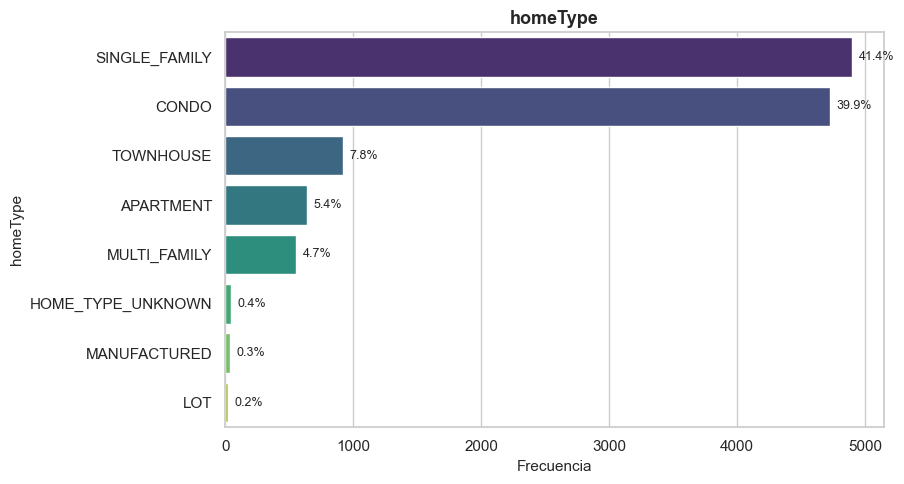


 ANÁLISIS DE CARDINALIDAD 


,Variable,Valores_Únicos,Porcentaje_Del_Total,Nivel_Cardinalidad
0,homeType,8,0.07,BAJA



 CONCLUSIONES DEL ANÁLISIS CATEGÓRICO 

1. DISTRIBUCIÓN DE CATEGORÍAS:
   - Revisa los gráficos de barras para identificar variables desbalanceadas.

2. VALORES FALTANTES:
   - Variables con >50% de valores faltantes podrían ser candidatas a eliminación.
   - Variables con <20% de faltantes pueden ser imputadas con la moda o "Desconocido".

3. ALTA CARDINALIDAD:
   - Variables con muchos valores únicos (>50) pueden causar overfitting.
   - Acción sugerida: Agrupar categorías raras o usar técnicas de encoding avanzadas.

4. CATEGORÍAS POCO FRECUENTES:
   - Si una categoría aparece menos del 1% de las veces, considera agruparla en "Other".

✅ Análisis categórico completado exitosamente.


In [ ]:

def plot_categorical_distributions(data, columns, max_categories=15):
    if not columns:
        print("No hay columnas para graficar.")
        return
    
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(columns):
        value_counts = data[col].value_counts()
        
        if len(value_counts) > max_categories:
            value_counts = value_counts.head(max_categories)
            title_suffix = f" (Top {max_categories})"
        else:
            title_suffix = ""
        
        sns.barplot(
            x=value_counts.values,
            y=value_counts.index.astype(str),
            ax=axes[i],
            palette='viridis',
            hue=value_counts.index.astype(str),
            legend=False
        )
        
        axes[i].set_title(f'{col}{title_suffix}', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Frecuencia', fontsize=11)
        axes[i].set_ylabel(col, fontsize=11)
        
        for j, v in enumerate(value_counts.values):
            pct = (v / len(data)) * 100
            axes[i].text(v + (max(value_counts.values)*0.01), j, f'{pct:.1f}%', va='center', fontsize=9)
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

if cols_to_analyze:
    print("\n📊 Generando gráficos de barras...")
    plot_categorical_distributions(df, cols_to_analyze)


# 4. Análisis de Cardinalidad (CORREGIDO)

In [ ]:
if cols_to_analyze:
    print("\n" + "="*60)
    print(" ANÁLISIS DE CARDINALIDAD ")
    print("="*60)
    
    # CORRECCIÓN AQUÍ: Usamos la función round() nativa de Python en lugar del método .round() de pandas
    cardinality_df = pd.DataFrame({
        'Variable': cols_to_analyze,
        'Valores_Únicos': [df[col].nunique() for col in cols_to_analyze],
        'Porcentaje_Del_Total': [round((df[col].nunique() / len(df)) * 100, 4) for col in cols_to_analyze]
    }).sort_values(by='Valores_Únicos', ascending=False)
    
    def classify_cardinality(n):
        if n > 50:
            return "ALTA"
        elif n >= 10:
            return "MEDIA"
        else:
            return "BAJA"
    
    cardinality_df['Nivel_Cardinalidad'] = cardinality_df['Valores_Únicos'].apply(classify_cardinality)
    display(cardinality_df)
    
    high_card = cardinality_df[cardinality_df['Nivel_Cardinalidad'] == "ALTA"]
    if not high_card.empty:
        print("\n⚠️ ALERTA: Las siguientes variables tienen ALTA cardinalidad:")
        for _, row in high_card.iterrows():
            print(f"   - {row['Variable']}: {row['Valores_Únicos']} valores únicos")
        print("   💡 Sugerencia: Considerar agrupar categorías poco frecuentes en 'Other' o usar Target Encoding.")



 ANÁLISIS DE CARDINALIDAD 


,Variable,Valores_Únicos,Porcentaje_Del_Total,Nivel_Cardinalidad
0,homeType,8,0.07,BAJA



 CONCLUSIONES DEL ANÁLISIS CATEGÓRICO 

1. DISTRIBUCIÓN DE CATEGORÍAS:
   - Revisa los gráficos de barras para identificar variables desbalanceadas.

2. VALORES FALTANTES:
   - Variables con >50% de valores faltantes podrían ser candidatas a eliminación.
   - Variables con <20% de faltantes pueden ser imputadas con la moda o "Desconocido".

3. ALTA CARDINALIDAD:
   - Variables con muchos valores únicos (>50) pueden causar overfitting.
   - Acción sugerida: Agrupar categorías raras o usar técnicas de encoding avanzadas.

4. CATEGORÍAS POCO FRECUENTES:
   - Si una categoría aparece menos del 1% de las veces, considera agruparla en "Other".

✅ Análisis categórico completado exitosamente.


# 5. Conclusiones del Análisis Categórico

In [8]:
print("\n" + "="*60)
print(" CONCLUSIONES DEL ANÁLISIS CATEGÓRICO ")
print("="*60)
print("""
1. DISTRIBUCIÓN DE CATEGORÍAS:
   - Revisa los gráficos de barras para identificar variables desbalanceadas.

2. VALORES FALTANTES:
   - Variables con >50% de valores faltantes podrían ser candidatas a eliminación.
   - Variables con <20% de faltantes pueden ser imputadas con la moda o "Desconocido".

3. ALTA CARDINALIDAD:
   - Variables con muchos valores únicos (>50) pueden causar overfitting.
   - Acción sugerida: Agrupar categorías raras o usar técnicas de encoding avanzadas.

4. CATEGORÍAS POCO FRECUENTES:
   - Si una categoría aparece menos del 1% de las veces, considera agruparla en "Other".
""")
print("="*60)
print("✅ Análisis categórico completado exitosamente.")


 CONCLUSIONES DEL ANÁLISIS CATEGÓRICO 

1. DISTRIBUCIÓN DE CATEGORÍAS:
   - Revisa los gráficos de barras para identificar variables desbalanceadas.

2. VALORES FALTANTES:
   - Variables con >50% de valores faltantes podrían ser candidatas a eliminación.
   - Variables con <20% de faltantes pueden ser imputadas con la moda o "Desconocido".

3. ALTA CARDINALIDAD:
   - Variables con muchos valores únicos (>50) pueden causar overfitting.
   - Acción sugerida: Agrupar categorías raras o usar técnicas de encoding avanzadas.

4. CATEGORÍAS POCO FRECUENTES:
   - Si una categoría aparece menos del 1% de las veces, considera agruparla en "Other".

✅ Análisis categórico completado exitosamente.
